<a href="https://www.kaggle.com/code/ashutoshiig2027/pneumofusionnet-v2-explainable-pneumonia-detect?scriptVersionId=321637848" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# PneumoFusionNet V2  
## Chest X-Ray Pneumonia Detection using ResNet50 + GCSA Attention + Depthwise Separable Convolution

### Project Overview
PneumoFusionNet V2 is a deep learning framework designed for automated pneumonia detection from chest X-ray images.  
The model combines:

- ResNet50 backbone
- Global Context Spatial Attention (GCSA)
- Depthwise Separable Convolution (DSC)
- Single-channel grayscale optimization

The project focuses on improving radiological feature extraction while maintaining computational efficiency and reproducibility.

---

## Key Features

- Medical imaging classification pipeline
- Grayscale chest X-ray preprocessing
- Attention-enhanced feature extraction
- Weighted data sampling for imbalance handling
- Training and evaluation visualization
- Research-oriented architecture design

---

## Dataset

Dataset Used:
- Chest X-Ray Pneumonia Dataset

Classes:
- NORMAL
- PNEUMONIA

---

## Research Motivation

Pneumonia remains a major respiratory disease worldwide.  
AI-assisted radiological systems can support clinicians by improving screening efficiency and reducing diagnostic workload.

---

## Model Workflow

Input X-ray  
→ Preprocessing  
→ ResNet50 Feature Extraction  
→ GCSA Attention  
→ Depthwise Separable Convolution  
→ Classification Head  
→ Pneumonia Prediction



## Notebook Structure

1. Environment Setup  
2. Dataset Loading  
3. Image Preprocessing  
4. Data Visualization  
5. Model Architecture  
6. Training Pipeline  
7. Validation & Testing  
8. Performance Metrics  
9. Result Visualization  
10. Model Saving  

---

## Author
IIT Guwahati
B.Sc. in Data Science & Artificial Intelligence, IIT Guwahati
📧 Email: ay346185@gmail.com

In [1]:
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_mpl
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda': print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [2]:
DATA_DIR    = '/kaggle/input/chest-xray-pneumonia/chest_xray'
if not os.path.exists(DATA_DIR):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train' in dirs and 'test' in dirs:
            DATA_DIR = root; print('Found:', DATA_DIR); break
SAVE_DIR    = '/kaggle/working'
MODEL_PATH  = os.path.join(SAVE_DIR, 'best_pneumofusion_model.pth')
IMG_SIZE=224; BATCH_SIZE=32; NUM_EPOCHS=25; LR=1e-4; WEIGHT_DECAY=1e-5; NUM_CLASSES=2
CLASSES=['NORMAL','PNEUMONIA']; MEAN=[0.449]; STD=[0.226]
print('Data dir:', DATA_DIR)
for s in ['train','val','test']:
    for c in CLASSES:
        p=os.path.join(DATA_DIR,s,c)
        n=len(os.listdir(p)) if os.path.exists(p) else 'MISSING'
        print(f'  {s}/{c}: {n}')

Found: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Data dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  val/NORMAL: 8
  val/PNEUMONIA: 8
  test/NORMAL: 234
  test/PNEUMONIA: 390


## Transforms — Grayscale (1 Channel)

In [3]:
tfms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}
print('Grayscale transforms ready.')

Grayscale transforms ready.


In [4]:
image_datasets = {
    s: datasets.ImageFolder(os.path.join(DATA_DIR, s), tfms[s])
    for s in ['train', 'val', 'test']
}
train_labels   = [s[1] for s in image_datasets['train'].samples]
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE,
                        sampler=sampler, num_workers=2, pin_memory=True),
    'val':   DataLoader(image_datasets['val'],   batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(image_datasets['test'],  batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True),
}
dataset_sizes = {s: len(image_datasets[s]) for s in ['train','val','test']}
print('Dataset sizes:', dataset_sizes)
print('Class index  :', image_datasets['train'].class_to_idx)
# Verify 1-channel input
sample_batch, _ = next(iter(dataloaders['train']))
print('Batch shape (B,C,H,W):', sample_batch.shape)  

Dataset sizes: {'train': 5216, 'val': 16, 'test': 624}
Class index  : {'NORMAL': 0, 'PNEUMONIA': 1}
Batch shape (B,C,H,W): torch.Size([32, 1, 224, 224])


## Visualise Sample Images

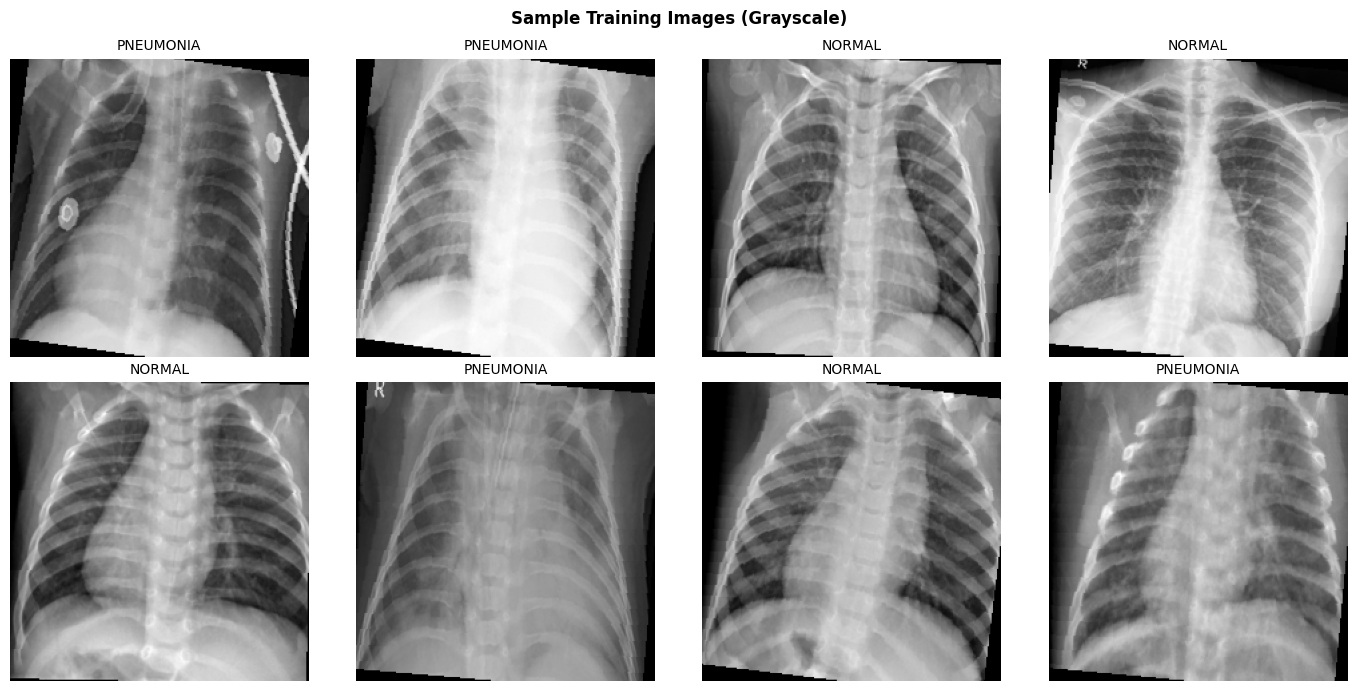

In [5]:
inputs, cls_idx = next(iter(dataloaders['train']))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    img = inputs[i].squeeze().numpy()
    img = img * STD[0] + MEAN[0]
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASSES[cls_idx[i].item()], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images (Grayscale)', fontweight='bold')
plt.tight_layout(); plt.show()

## Model: PneumoFusionNet with 1-Channel ResNet50 + GCSA + DSC

In [6]:
def get_resnet50_1ch():
    model = models.resnet50(pretrained=True)

    # Replace first conv layer (3 → 1 channel)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Initialize weights from pretrained
    with torch.no_grad():
        model.conv1.weight = nn.Parameter(
            model.conv1.weight.mean(dim=1, keepdim=True)
        )

    return model

In [7]:
class GCSA(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

        self.sigmoid = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        B, C, H, W = x.shape

        # Channel attention
        avg = self.avg_pool(x).view(B, C)
        max_ = self.max_pool(x).view(B, C)

        channel_att = self.sigmoid(self.mlp(avg) + self.mlp(max_)).view(B, C, 1, 1)
        x = x * channel_att

        # Spatial attention
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)

        spatial = torch.cat([avg, max_], dim=1)
        spatial_att = self.sigmoid(self.conv_spatial(spatial))

        return x * spatial_att

In [8]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return self.relu(self.bn(x))

In [9]:
class PneumoFusionNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        resnet = get_resnet50_1ch()

        # Remove FC layer
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Add proposed improvements
        self.dsc = DepthwiseSeparableConv(2048, 1024)
        self.gcsa = GCSA(1024)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
         nn.Dropout(0.5),
         nn.Linear(1024, num_classes))
                            


    def forward(self, x):   # ✅ aligned properly
        x = self.backbone(x)      # ResNet output
        x = self.dsc(x)           # DSC
        x = self.gcsa(x)          # Attention
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [10]:

model = PneumoFusionNet(num_classes=2)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


# Training Configuration

The model uses:
- AdamW optimizer
- CrossEntropyLoss
- Learning rate scheduling
- GPU acceleration

## Loss Function & Optimization Strategy

In [11]:
criterion = nn.CrossEntropyLoss()



optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,   # ↓ lower learning rate
    weight_decay=1e-4
)


In [12]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,     # restart cycle
    eta_min=1e-6
)

## Training Pipeline

## Model Training Function

The following function performs:
- forward propagation
- loss computation
- backpropagation
- optimizer updates
- batch accuracy tracking

Training metrics are aggregated for epoch-level evaluation.


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

## Validation Pipeline

## Model Evaluation

Validation is performed after each training epoch to monitor:
- generalization capability
- overfitting
- classification performance

Evaluation metrics are calculated on unseen validation data.


In [14]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

# DataLoaders for training

In [15]:
train_loader = dataloaders['train']
val_loader   = dataloaders['val']
test_loader  = dataloaders['test']

## Train 25 Epoch

In [16]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

In [17]:
import os

os.makedirs('results', exist_ok=True)
os.makedirs('results/gradcam', exist_ok=True)

In [18]:
num_epochs = 25
best_acc  = 0
best_loss = float('inf')
patience = 3
counter  = 0
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_acc = validate(
        model, val_loader, criterion, DEVICE
    )
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )
    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_acc:.2f}%"
    )
    # Save best accuracy model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "results/best_model_acc.pth"
        )
        print("Best accuracy model saved!")
    # Early Stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "results/best_model_loss.pth"
        )
        print("Best loss model saved!")
    else:
        counter += 1
        print(
            f"EarlyStopping Counter: "
            f"{counter}/{patience}"
        )
    # Stop training
    if counter >= patience:
        print("\nEarly stopping triggered!")
        break

Epoch 1/25
Train Loss: 0.1488 | Train Acc: 94.56%
Val Loss:   0.4450 | Val Acc:   81.25%
Best accuracy model saved!
Best loss model saved!
Epoch 2/25
Train Loss: 0.0973 | Train Acc: 96.57%
Val Loss:   0.2934 | Val Acc:   93.75%
Best accuracy model saved!
Best loss model saved!
Epoch 3/25
Train Loss: 0.1043 | Train Acc: 95.97%
Val Loss:   0.1908 | Val Acc:   93.75%
Best loss model saved!
Epoch 4/25
Train Loss: 0.0629 | Train Acc: 97.85%
Val Loss:   0.3127 | Val Acc:   87.50%
EarlyStopping Counter: 1/3
Epoch 5/25
Train Loss: 0.0630 | Train Acc: 97.62%
Val Loss:   0.3187 | Val Acc:   81.25%
EarlyStopping Counter: 2/3
Epoch 6/25
Train Loss: 0.0447 | Train Acc: 98.29%
Val Loss:   0.1943 | Val Acc:   93.75%
EarlyStopping Counter: 3/3

Early stopping triggered!


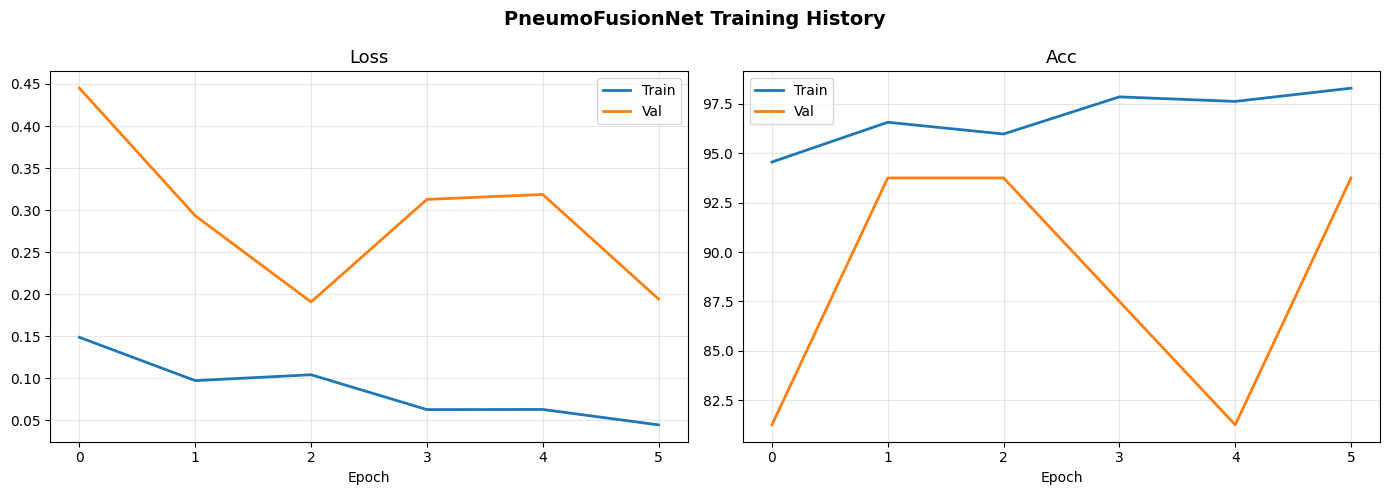

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['loss', 'acc']):
    ax.plot(history[f'train_{metric}'], label='Train', linewidth=2)
    ax.plot(history[f'val_{metric}'],   label='Val',   linewidth=2)
    ax.set_title(metric.capitalize(), fontsize=13)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('PneumoFusionNet Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Final Evaluation on Test Set

  Accuracy : 92.15%
  ROC-AUC  : 0.9776
              precision    recall  f1-score   support

      NORMAL       0.96      0.83      0.89       234
   PNEUMONIA       0.90      0.98      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



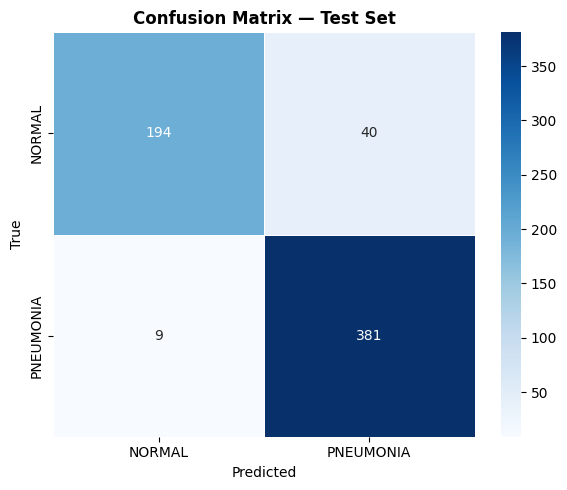

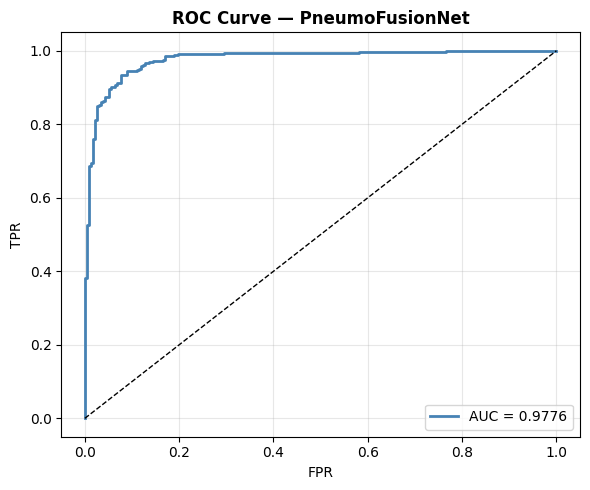

In [20]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X, y in dataloaders['test']:
        X = X.to(DEVICE)
        out = model(X)
        probs = F.softmax( out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
        all_probs.extend(probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ============================
# Metrics
# ============================
acc = accuracy_score(
    all_labels,
    all_preds
)
auc = roc_auc_score(
    all_labels,
    all_probs
)
print('=' * 55)
print(f'  Accuracy : {acc * 100:.2f}%')
print(f'  ROC-AUC  : {auc:.4f}')

# ============================
# Classification Report
# ============================

report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASSES
)

print(report)
with open('results/classification_report.txt','w'
) as f:
    f.write(report)
# Confusion Matrix
cm = confusion_matrix(all_labels,all_preds)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASSES,yticklabels=CLASSES, linewidths=0.5,ax=ax)
ax.set_title(
    'Confusion Matrix — Test Set',
    fontweight='bold'
)
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
# Save Confusion Matrix
fig.savefig(
    'results/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
# ROC Curve
fpr, tpr, _ = roc_curve(
    all_labels,
    all_probs
)
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(fpr,tpr,lw=2,color='steelblue',label=f'AUC = {auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(
    'ROC Curve — PneumoFusionNet',
    fontweight='bold'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# Save ROC Curve
fig.savefig(
    'results/roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Grad-CAM Visualization

Grad-CAM helps visualize which chest X-ray regions contributed most to the model prediction.

This improves interpretability and explainability in medical imaging AI systems.

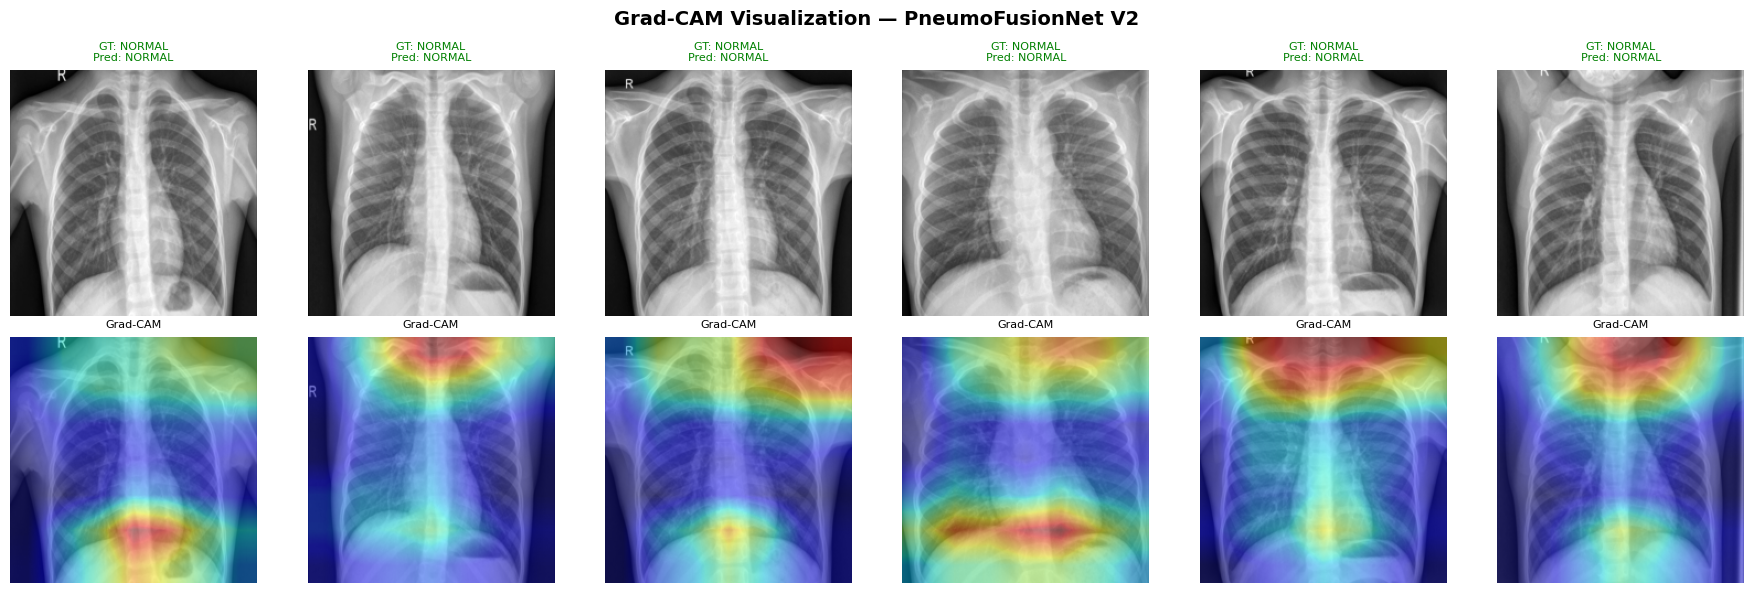

In [21]:

class GradCAM:

    def __init__(self, model, layer):

        self.model = model
        self.grads = None
        self.acts = None
        self.handles = []

        # Forward Hook
        self.handles.append(
            layer.register_forward_hook(self._save_acts)
        )

        # Backward Hook
        self.handles.append(
            layer.register_full_backward_hook(self._save_grads)
        )

    # Save Activations
    def _save_acts(self, module, input, output):

        self.acts = output.detach()

    # Save Gradients
    def _save_grads(self, module, grad_input, grad_output):

        self.grads = grad_output[0].detach()

    # Remove Hooks
    def remove_hooks(self):

        for h in self.handles:
            h.remove()

    # Generate GradCAM
    def generate(self, x, idx=None):

        self.model.eval()

        output = self.model(x)

        # Predicted Class
        if idx is None:
            idx = output.argmax(dim=1).item()

        # Backpropagation
        self.model.zero_grad()

        output[0, idx].backward()

        # Global Average Pooling on Gradients
        weights = self.grads.mean(dim=[2, 3], keepdim=True)

        # Weighted Activations
        cam = (weights * self.acts).sum(dim=1, keepdim=True)

        # ReLU
        cam = F.relu(cam)

        # Resize Heatmap
        cam = F.interpolate(
            cam,
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        )

        # Normalize
        cam = cam.squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, idx



def show_gradcam(model, loader, n=6):

    # IMPORTANT:
    # Hooking into custom GCSA attention block
    gc = GradCAM(model, model.gcsa)

    X, y = next(iter(loader))

    X = X.to(DEVICE)
    y = y.to(DEVICE)

    fig, axes = plt.subplots(2, n, figsize=(18, 6))

    for i in range(n):

        # Generate CAM
        cam, pred_idx = gc.generate(X[i:i+1])
        
        # Original Image
      

        orig = X[i].squeeze().cpu().numpy()

        # Denormalize
        orig = orig * STD[0] + MEAN[0]

        orig = np.clip(orig, 0, 1)

        axes[0, i].imshow(orig, cmap='gray')

        axes[0, i].axis('off')

        # Prediction Color
        color = 'green' if pred_idx == y[i].item() else 'red'

        axes[0, i].set_title(
            f'GT: {CLASSES[y[i]]}\nPred: {CLASSES[pred_idx]}',
            fontsize=8,
            color=color
        )

        # ====================================
        # Heatmap Overlay
        # ====================================

        heatmap = cm_mpl.jet(cam)[:, :, :3]

        orig_rgb = np.stack([orig] * 3, axis=-1)

        overlay = np.clip(
            0.55 * orig_rgb + 0.45 * heatmap,
            0,
            1
        )

        axes[1, i].imshow(overlay)

        axes[1, i].axis('off')

        axes[1, i].set_title(
            'Grad-CAM',
            fontsize=8
        )
    # Main Title
    plt.suptitle(
        'Grad-CAM Visualization — PneumoFusionNet V2',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(f'results/gradcam/gradcam.png')
    plt.show()

    # Remove hooks after visualization
    gc.remove_hooks()
show_gradcam(
    model,
    dataloaders['test'],
    n=6
)

## Single Image Inference

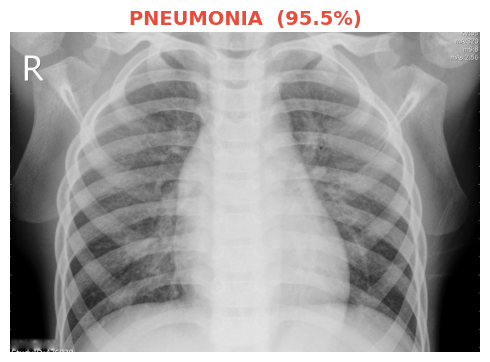

NORMAL    : 4.53%
PNEUMONIA : 95.47%


('PNEUMONIA', 0.9547420144081116)

In [22]:
def predict_single(path, model):
    model.eval()
    img = Image.open(path).convert('L')  # Grayscale
    t   = tfms['test'](img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out  = model(t)
        prob = F.softmax(out, dim=1)[0]
        pi   = prob.argmax().item()
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray'); plt.axis('off')
    col = '#e74c3c' if pi == 1 else '#2ecc71'
    plt.title(f'{CLASSES[pi]}  ({prob[pi]*100:.1f}%)',
              color=col, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'NORMAL    : {prob[0]*100:.2f}%')
    print(f'PNEUMONIA : {prob[1]*100:.2f}%')
    return CLASSES[pi], prob[pi].item()

sample = os.path.join(DATA_DIR,'test','PNEUMONIA',
         os.listdir(os.path.join(DATA_DIR,'test','PNEUMONIA'))[0])
predict_single(sample, model)

# Final Results Summary

PneumoFusionNet V2 successfully combines:

- ResNet50 Backbone
- GCSA Attention
- Depthwise Separable Convolution
- Grad-CAM Explainability

for chest X-ray pneumonia detection.

The model demonstrates strong medical imaging performance while maintaining explainability and efficient feature extraction.

# Note

This project is developed for research and educational purposes in medical imaging and deep learning.

The model predictions are not intended for direct clinical diagnosis and should only be used as an AI-assisted analysis tool.

Future improvements and larger-scale validation are required before any real-world medical deployment.

# Future Research Direction

The next phase of PneumoFusionNet will focus on developing a multimodal medical AI system by integrating:

- Chest X-ray image analysis
- Clinical text understanding
- Radiology report generation
- Vision-language learning models
- Explainable multimodal AI

The future architecture will combine radiological imaging features with clinical information such as:
- patient history
- symptoms
- findings
- impressions
- diagnostic reports

This will enable:
- automated clinical report generation
- multimodal disease understanding
- improved diagnostic support systems
- AI-assisted radiology workflows

Future work will also include:
- MIMIC-CXR + MIMIC-IV integration
- Transformer-based multimodal architectures
- Large Vision Language Models (LVLMs)
- Retrieval-Augmented Generation (RAG)
- Medical report summarization
- Cross-modal attention mechanisms